# MVP — Machine Learning & Analytics

**Nome:** Fabiola Dias Carvalho  
**Matrícula:** 4052023001431  
**Data:** 20/06/2026  
**Dataset:** Wine Quality (Red Wine) — [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/186/wine+quality)  
**Repositório GitHub:** [https://github.com/diasfabi7-prog/Machine_analytics
](https://github.com/diasfabi7-prog/Machine_analytics)  
**Tipo de problema:** Classificação  

---


## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | OK |
| Dataset descrito, com fonte, atributos e restrições | OK |
| Dataset carregado por URL pública ou fonte diretamente acessível | OK |
| Análise exploratória objetiva, conectada à modelagem | OK |
| Divisão adequada em treino/teste e, se aplicável, validação | OK |
| Prevenção de vazamento de dados | OK |
| Tratamentos de dados justificados | OK |
| Pipeline ou sequência reprodutível de pré-processamento | OK |
| Modelo baseline definido | OK |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | OK |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | OK |
| Avaliação com métricas coerentes com o problema | OK |
| Discussão de overfitting/underfitting, limitações e melhorias | OK |
| Código limpo, organizado e executável do início ao fim | OK |
| Conclusão conectada ao objetivo inicial | OK |


# 1. Definição do problema

## 1.1 Descrição do problema

A ideia deste projeto surgiu de uma pergunta simples: é possível saber se um vinho é bom só olhando para os números do laboratório, sem depender de um sommelier?

Avaliar a qualidade de um vinho manualmente é caro, lento e subjetivo, dois especialistas podem dar notas diferentes para a mesma amostra. Por outro lado, propriedades físico-químicas como acidez, teor alcoólico e pH são medidas objetivas, baratas e fáceis de obter em qualquer laboratório de controle de qualidade.

A proposta deste MVP é usar essas medições para treinar um modelo de classificação capaz de indicar se um vinho tinto tende a ser de alta ou baixa qualidade. Isso poderia apoiar produtores em uma triagem inicial de lotes antes de acionar um painel de especialistas, economizando tempo e dinheiro.

O dataset escolhido é o **Wine Quality (Red Wine)**, do UCI Machine Learning Repository, publicado por Cortez et al. (2009). É um dataset público, sem dados pessoais, bem documentado e amplamente usado como referência em problemas de classificação tabular, o que facilita a reprodução e a comparação dos resultados.

## 1.2 Objetivo do MVP

Construir e comparar modelos de Machine Learning para classificar vinhos tintos como **alta** ou **baixa qualidade** a partir de suas propriedades físico-químicas, avaliando se essa abordagem consegue superar um baseline ingênuo e identificando quais variáveis mais influenciam o resultado.

## 1.3 Tipo de problema

**Tipo escolhido:** Classificação binária.

O dataset original traz notas de 0 a 10 atribuídas por especialistas. Ao observar a distribuição das notas, percebe-se que a esmagadora maioria dos vinhos recebe nota 5 ou 6, enquanto notas extremas (3 ou 8–9) são raríssimas. Uma classificação multiclasse ficaria extremamente desbalanceada e de difícil avaliação, com classes praticamente sem exemplos.

Por isso, optou-se por binarizar o target: nota ≥ 6 vira **"alta qualidade"** (classe 1) e nota ≤ 5 vira **"baixa qualidade"** (classe 0). Essa simplificação é comum na literatura sobre este dataset e também faz sentido do ponto de vista prático, a decisão que importa para o produtor é, essencialmente, "esse lote passa ou não passa no controle de qualidade".

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. O teor alcoólico deve ter correlação positiva com a qualidade, vinhos mais encorpados tendem a ser mais bem avaliados.
2. A acidez volátil alta deve prejudicar a nota, já que altos níveis de ácido acético causam gosto de vinagre, considerado um defeito sensorial.
3. Sulfatos e dióxido de enxofre devem ter comportamento mais ambíguo: ajudam na conservação, mas em excesso prejudicam o sabor.

**Critérios de sucesso:**
- **Métrica principal:** F1-score ponderado (weighted), por conta do desbalanceamento moderado entre as classes.
- **Resultado mínimo esperado:** superar o baseline (que apenas prevê a classe majoritária) em pelo menos 10 pontos percentuais de F1-score.
- **Restrição prática:** o tempo total de treino deve ser viável em CPU comum (ambiente padrão do Google Colab), sem necessidade de GPU.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne as importações, a configuração da seed de reprodutibilidade e informações básicas do ambiente de execução. Todas as bibliotecas utilizadas já vêm pré-instaladas no Google Colab, não sendo necessária nenhuma instalação adicional.

In [4]:
#Setup básico e reprodutibilidade
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = {"baixa": "#8E2A3A", "alta": "#2E6E5C", "neutro": "#37474F", "destaque": "#C9A227"}

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Seed fixada em:", SEED)

Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Seed fixada em: 42


## 2.1 Dependências adicionais

Não foram necessárias bibliotecas além das já disponíveis por padrão no Google Colab (`numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `scipy`).

## 2.2 Funções auxiliares

Funções utilitárias para evitar repetição de código ao longo do notebook, especialmente no cálculo de métricas e na exibição de resultados comparativos entre modelos.

In [5]:
def evaluate_classification(y_true, y_pred, proba=None, train_time=None):
    """Calcula métricas de classificação binária relevantes para este problema."""
    result = {
        "Acurácia": round(accuracy_score(y_true, y_pred), 4),
        "Precisão": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1 (weighted)": round(f1_score(y_true, y_pred, average="weighted"), 4),
        "F1 (classe alta)": round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
    }
    if proba is not None:
        try:
            result["ROC-AUC"] = round(roc_auc_score(y_true, proba[:, 1]), 4)
        except Exception:
            result["ROC-AUC"] = np.nan
    else:
        result["ROC-AUC"] = np.nan
    result["Tempo treino (s)"] = round(train_time, 3) if train_time is not None else np.nan
    return result


def show_results_table(results_dict):
    """Converte um dicionário de resultados em uma tabela ordenável por F1 (weighted)."""
    tabela = pd.DataFrame(results_dict).T
    return tabela.sort_values("F1 (weighted)", ascending=False)


def plot_metric_comparison(tabela, metric="F1 (weighted)", title=None):
    """Gráfico de barras comparando um modelo por métrica escolhida."""
    ordenado = tabela[metric].sort_values()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    cores = plt.cm.viridis(np.linspace(0.25, 0.9, len(ordenado)))
    bars = ax.barh(ordenado.index, ordenado.values, color=cores, edgecolor="white")
    for bar, valor in zip(bars, ordenado.values):
        ax.text(valor + 0.005, bar.get_y() + bar.get_height() / 2, f"{valor:.3f}",
                va="center", fontsize=9)
    ax.set_xlabel(metric)
    ax.set_title(title or f"Comparação de modelos — {metric}")
    ax.set_xlim(0, min(1.05, ordenado.max() * 1.15))
    plt.tight_layout()
    plt.show()

print("Funções auxiliares definidas: evaluate_classification, show_results_table, plot_metric_comparison")

Funções auxiliares definidas: evaluate_classification, show_results_table, plot_metric_comparison


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Dataset:** Wine Quality — Red Wine
**Fonte:** UCI Machine Learning Repository — https://archive.ics.uci.edu/dataset/186/wine+quality
**Referência:** Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). *Modeling wine preferences by data mining from physicochemical properties.* Decision Support Systems, 47(4), 547–553.
**Licença:** CC BY 4.0 (uso público e livre, incluindo fins acadêmicos)

Esse dataset foi escolhido por dois motivos: (1) representa um problema real, com variáveis que possuem significado físico-químico concreto, e não apenas números soltos; (2) não há dados pessoais, sensíveis ou qualquer restrição de privacidade, é seguro de usar e compartilhar integralmente.

## 3.2 Carga dos dados

O dataset poderia ser carregado diretamente via URL pública do UCI, em formato CSV separado por ponto e vírgula, porém, como solicitado no documento, a base foi baixada em CSV e carregada no repositório do GitHub.

In [6]:
# Carga dos dados
DATA_URL = "https://raw.githubusercontent.com/diasfabi7-prog/Machine_analytics/refs/heads/main/winequality-red.csv"

df_raw = pd.read_csv(DATA_URL, sep=";")

print("Dataset carregado com sucesso!")
print(f"Shape: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
df_raw.head()

Dataset carregado com sucesso!
Shape: 1599 linhas x 12 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3.3 Visão geral do dataset

In [7]:
print("Formato do dataset:", df_raw.shape)
print("\nTipos de dados:")
display(df_raw.dtypes.to_frame("tipo"))

Formato do dataset: (1599, 12)

Tipos de dados:


,tipo
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [8]:
print("Valores ausentes por coluna:")
missing = df_raw.isna().sum()
display(missing.to_frame("ausentes"))
print("\nTotal de valores ausentes no dataset:", missing.sum())

Valores ausentes por coluna:


,ausentes
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Total de valores ausentes no dataset: 0


In [9]:
n_dup = df_raw.duplicated().sum()
print(f"Linhas duplicadas: {n_dup} ({100*n_dup/len(df_raw):.1f}% do total)")
print("\nNão há colunas de ID, data ou texto livre neste dataset, todos os atributos são numéricos")
print("e potencialmente relevantes para o modelo, exceto a própria coluna 'quality' (o target original).")

Linhas duplicadas: 240 (15.0% do total)

Não há colunas de ID, data ou texto livre neste dataset, todos os atributos são numéricos
e potencialmente relevantes para o modelo, exceto a própria coluna 'quality' (o target original).


In [10]:
display(df_raw.sample(5, random_state=SEED))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
803,7.7,0.56,0.08,2.50,0.114,14.0,46.0,0.9971,3.24,0.66,9.6,6
124,7.8,0.50,0.17,1.60,0.082,21.0,102.0,0.9960,3.39,0.48,9.5,5
350,10.7,0.67,0.22,2.70,0.107,17.0,34.0,1.0004,3.28,0.98,9.9,6
682,8.5,0.46,0.31,2.25,0.078,32.0,58.0,0.9980,3.33,0.54,9.8,5
1326,6.7,0.46,0.24,1.70,0.077,18.0,34.0,0.9948,3.39,0.60,10.6,6


In [11]:
display(df_raw.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


## 3.4 Dicionário de dados

São 1.599 registros e 12 colunas, todas numéricas contínuas. Cada linha representa uma amostra de vinho tinto analisada em laboratório.

| Coluna | Tipo | Descrição | Usada no modelo? | Observações |
|---|---|---|---|---|
| `fixed acidity` | numérica | Acidez fixa — ácido tartárico (g/L) | sim | — |
| `volatile acidity` | numérica | Acidez volátil — ácido acético (g/L) | sim | Excesso causa gosto de vinagre |
| `citric acid` | numérica | Ácido cítrico (g/L) | sim | Adiciona frescor ao vinho |
| `residual sugar` | numérica | Açúcar residual após fermentação (g/L) | sim | — |
| `chlorides` | numérica | Teor de sal (g/L) | sim | — |
| `free sulfur dioxide` | numérica | SO₂ livre (mg/L) | sim | Age como conservante |
| `total sulfur dioxide` | numérica | SO₂ total (mg/L) | sim | — |
| `density` | numérica | Densidade do líquido (g/mL) | sim | Correlacionada com açúcar/álcool |
| `pH` | numérica | Acidez geral | sim | — |
| `sulphates` | numérica | Sulfatos (g/L) | sim | Antioxidante/conservante |
| `alcohol` | numérica | Teor alcoólico (% vol.) | sim | — |
| `quality` | inteira (0–10) | Nota de qualidade dada por especialistas | **alvo original** | Binarizada em `quality_bin` (seção 5) |

**Limitações conhecidas do dataset:**
- Todos os vinhos são da região do Minho, Portugal, o modelo provavelmente não generaliza bem para vinhos de outras regiões/uvas.
- As notas foram atribuídas por um pequeno painel de avaliadores (mediana de 3 avaliações por amostra), o que introduz alguma subjetividade.
- O ano da safra não está disponível, embora seja uma variável potencialmente relevante.

# 4. Análise exploratória dos dados

Antes de modelar, é importante entender como os dados estão distribuídos, verificar o desbalanceamento do target e checar se as hipóteses da seção 1.4 fazem sentido nos dados reais.

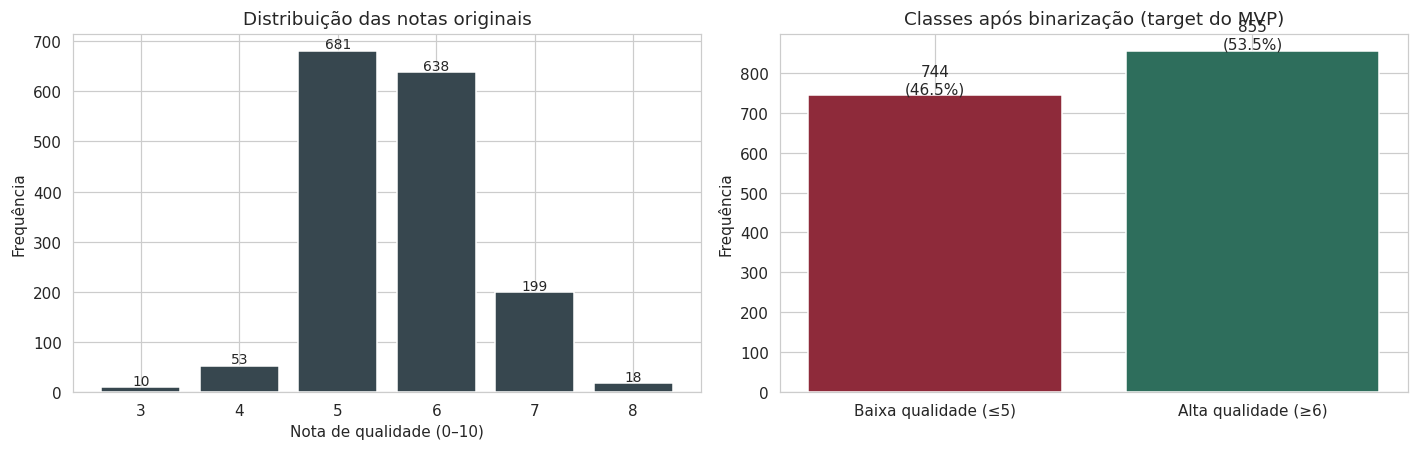

Desbalanceamento: 744 baixa qualidade vs 855 alta qualidade
Razão de desbalanceamento: 1 : 1.15
Classificado como desbalanceamento moderado (não severo) — F1 ponderado é a métrica mais indicada.


In [12]:
# Distribuição da variável-alvo original e após a binarização
df_raw["quality_bin"] = (df_raw["quality"] >= 6).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

contagem = df_raw["quality"].value_counts().sort_index()
axes[0].bar(contagem.index, contagem.values, color=PALETTE["neutro"], edgecolor="white")
axes[0].set_xlabel("Nota de qualidade (0–10)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição das notas originais")
for nota, freq in zip(contagem.index, contagem.values):
    axes[0].text(nota, freq + 5, str(freq), ha="center", fontsize=9)

contagem_bin = df_raw["quality_bin"].value_counts().sort_index()
labels = ["Baixa qualidade (≤5)", "Alta qualidade (≥6)"]
cores_bin = [PALETTE["baixa"], PALETTE["alta"]]
axes[1].bar(labels, contagem_bin.values, color=cores_bin, edgecolor="white")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Classes após binarização (target do MVP)")
for i, freq in enumerate(contagem_bin.values):
    axes[1].text(i, freq + 5, f"{freq}\n({100*freq/len(df_raw):.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Desbalanceamento: {contagem_bin[0]} baixa qualidade vs {contagem_bin[1]} alta qualidade")
print(f"Razão de desbalanceamento: 1 : {contagem_bin[1]/contagem_bin[0]:.2f}")
print("Classificado como desbalanceamento moderado (não severo) — F1 ponderado é a métrica mais indicada.")

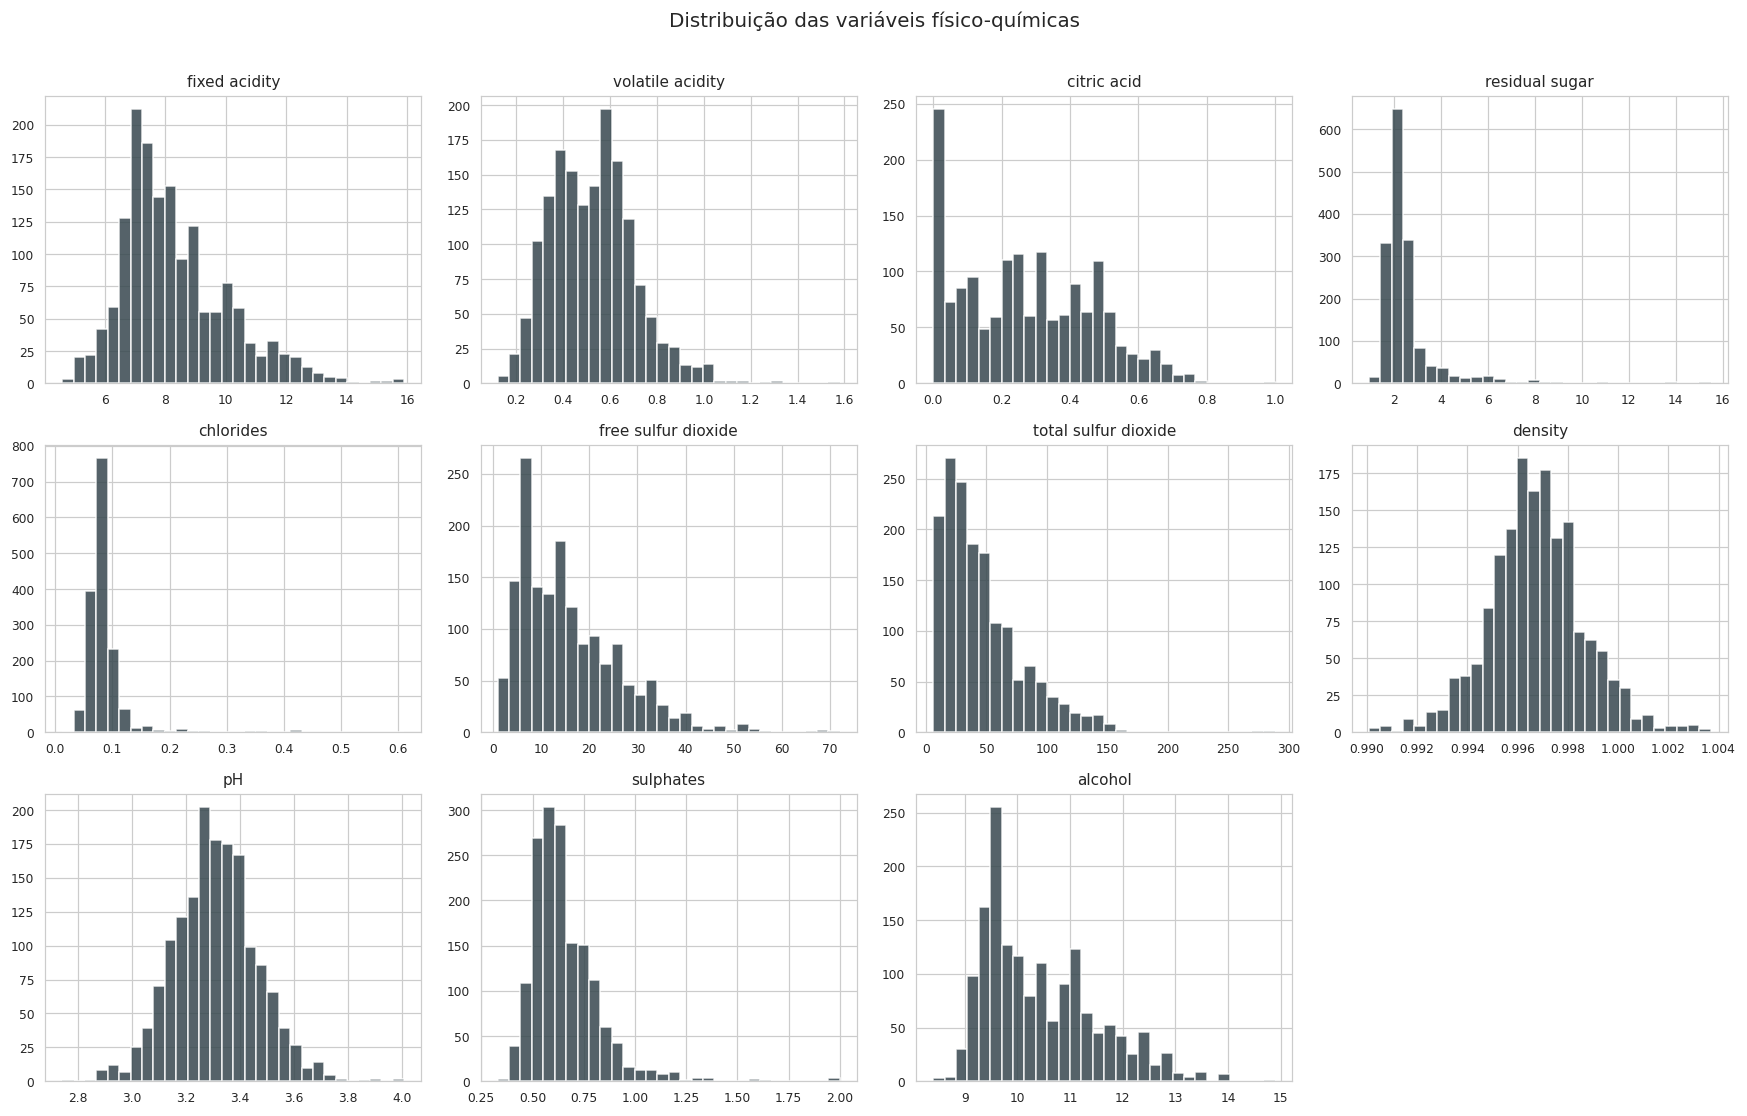

In [13]:
# Distribuição de todas as features numéricas (grade de histogramas)
features_all = [c for c in df_raw.columns if c not in ["quality", "quality_bin"]]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(features_all):
    axes[i].hist(df_raw[col], bins=30, color=PALETTE["neutro"], edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)
axes[-1].axis("off")
fig.suptitle("Distribuição das variáveis físico-químicas", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

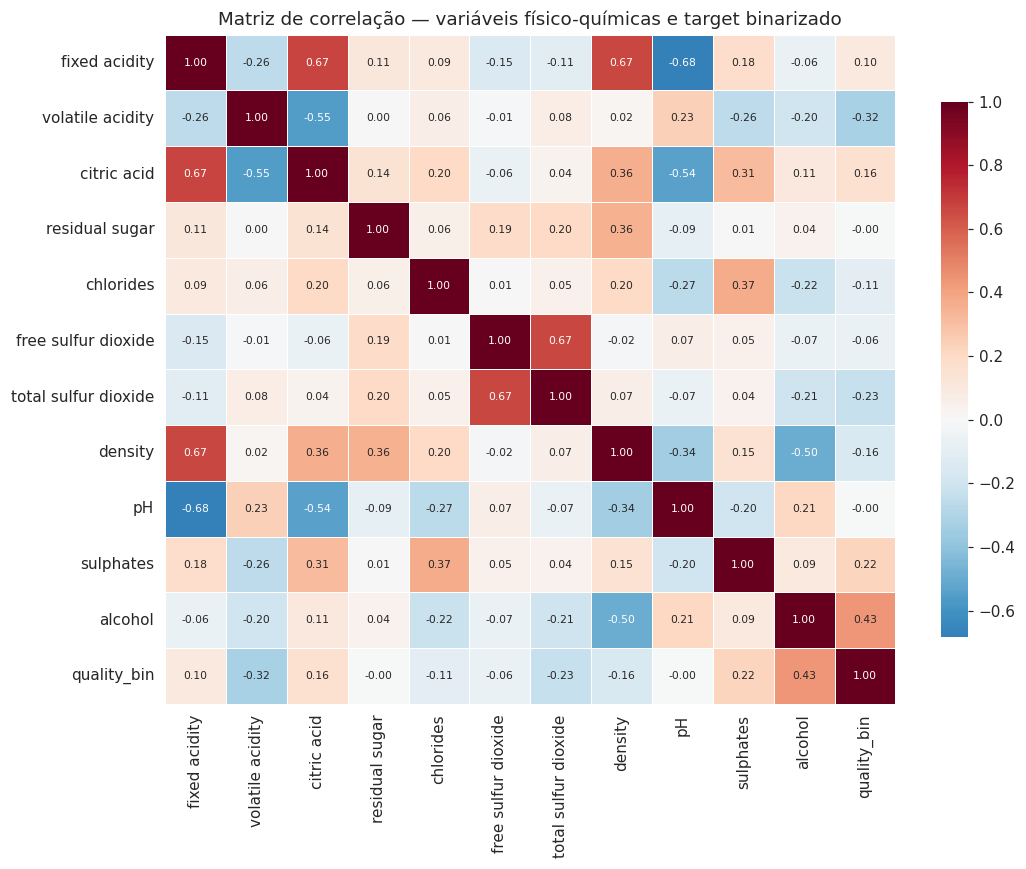

In [14]:
# Matriz de correlação completa entre as features
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_raw[features_all + ["quality_bin"]].corr()
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=0.4, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de correlação — variáveis físico-químicas e target binarizado")
plt.tight_layout()
plt.show()

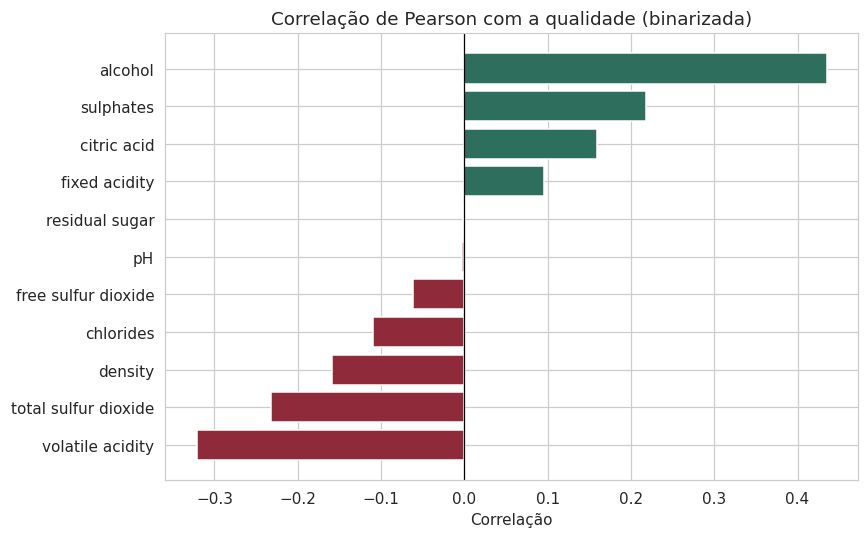

Top 3 correlações positivas (favorecem alta qualidade):
alcohol        0.434751
sulphates      0.218072
citric acid    0.159129

Top 3 correlações negativas (prejudicam a qualidade):
volatile acidity       -0.321441
total sulfur dioxide   -0.231963
density                -0.159110


In [15]:
# Correlação de cada feature com o target binarizado
corr_target = corr_matrix["quality_bin"].drop("quality_bin").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE["baixa"] if v < 0 else PALETTE["alta"] for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação de Pearson com a qualidade (binarizada)")
ax.set_xlabel("Correlação")
plt.tight_layout()
plt.show()

print("Top 3 correlações positivas (favorecem alta qualidade):")
print(corr_target.nlargest(3).to_string())
print("\nTop 3 correlações negativas (prejudicam a qualidade):")
print(corr_target.nsmallest(3).to_string())

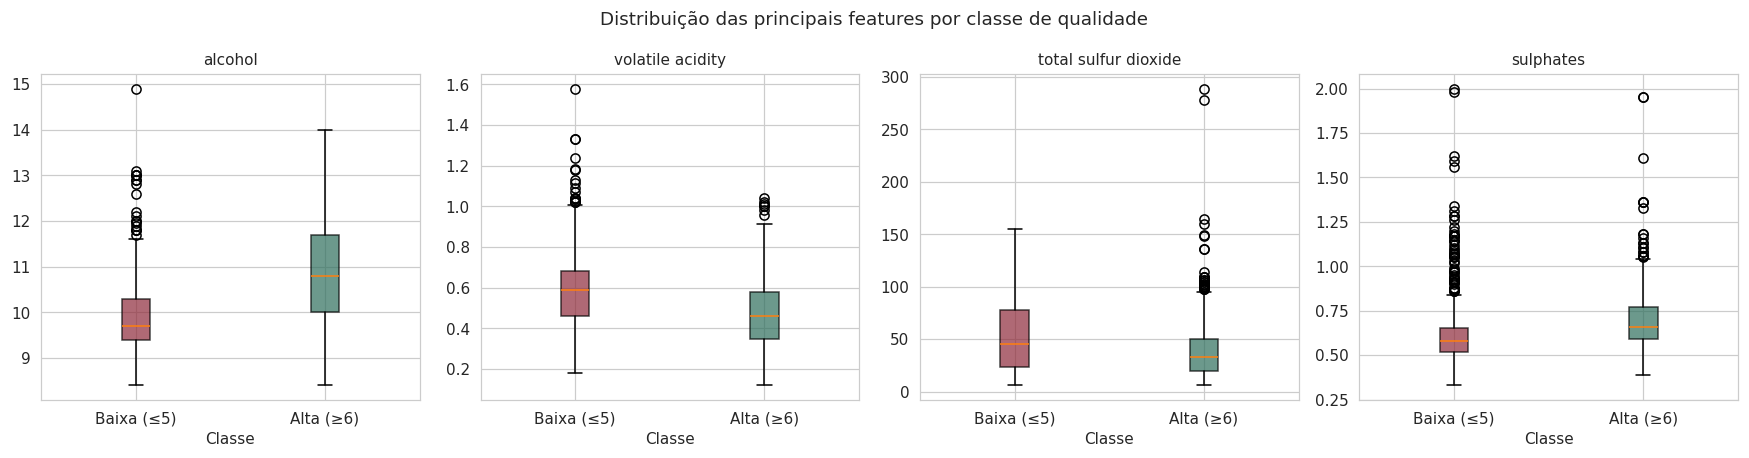

In [16]:
# Boxplots das features mais relevantes, separadas por classe
top_features = corr_target.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for i, feat in enumerate(top_features):
    dados = [df_raw[df_raw["quality_bin"] == 0][feat], df_raw[df_raw["quality_bin"] == 1][feat]]
    bp = axes[i].boxplot(dados, labels=["Baixa (≤5)", "Alta (≥6)"], patch_artist=True)
    for patch, cor in zip(bp["boxes"], [PALETTE["baixa"], PALETTE["alta"]]):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("Classe")

fig.suptitle("Distribuição das principais features por classe de qualidade", fontsize=12)
plt.tight_layout()
plt.show()

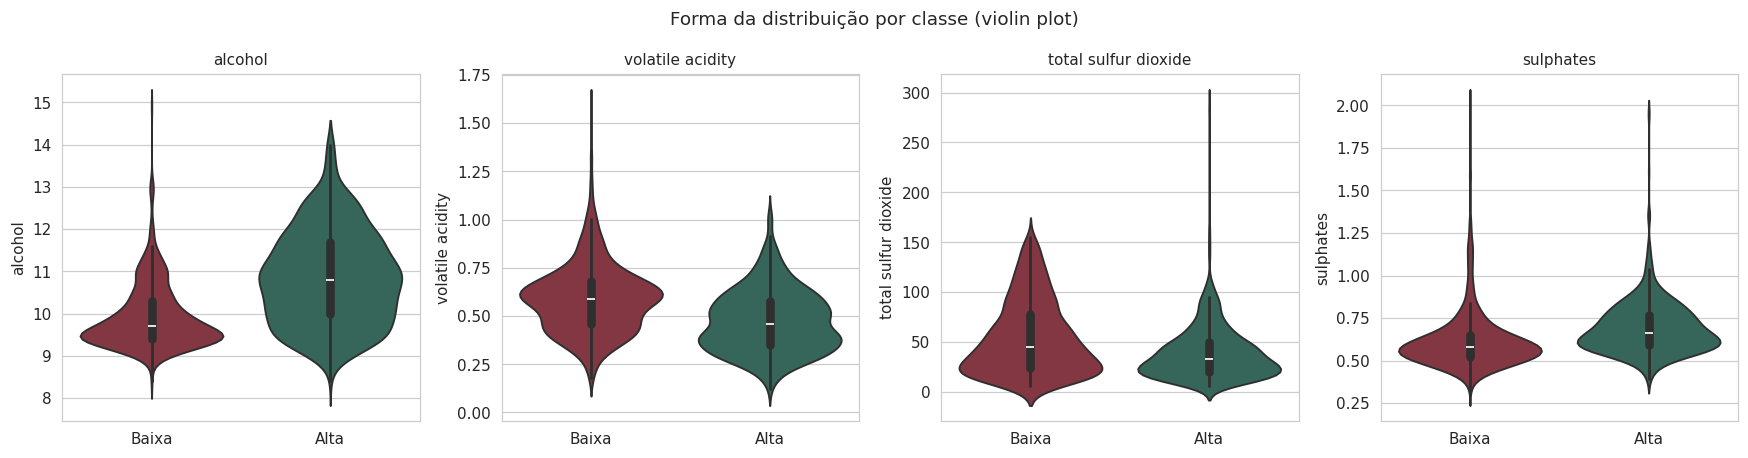

Observações:
- 'alcohol': vinhos de alta qualidade têm teor alcoólico visivelmente maior — confirma a hipótese 1.
- 'volatile acidity': vinhos de baixa qualidade têm acidez volátil maior — confirma a hipótese 2.
- 'sulphates': nível ligeiramente mais alto nos vinhos de alta qualidade.
- As distribuições se sobrepõem bastante, o que sugere que nenhuma feature isolada separa bem
  as classes; um modelo capaz de combinar várias variáveis deve performar melhor que regras simples.


In [17]:
# Violin plots complementares para observar a forma completa da distribuição
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for i, feat in enumerate(top_features):
    sns.violinplot(
        data=df_raw, x="quality_bin", y=feat, ax=axes[i],
        palette=[PALETTE["baixa"], PALETTE["alta"]], hue="quality_bin", legend=False
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Baixa", "Alta"])
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("")
fig.suptitle("Forma da distribuição por classe (violin plot)", fontsize=12)
plt.tight_layout()
plt.show()

print("Observações:")
print("- 'alcohol': vinhos de alta qualidade têm teor alcoólico visivelmente maior — confirma a hipótese 1.")
print("- 'volatile acidity': vinhos de baixa qualidade têm acidez volátil maior — confirma a hipótese 2.")
print("- 'sulphates': nível ligeiramente mais alto nos vinhos de alta qualidade.")
print("- As distribuições se sobrepõem bastante, o que sugere que nenhuma feature isolada separa bem")
print("  as classes; um modelo capaz de combinar várias variáveis deve performar melhor que regras simples.")

## 4.1 Síntese da análise exploratória

- **O target está desbalanceado, mas moderadamente:** aproximadamente 53% dos vinhos são classificados como baixa qualidade e 47% como alta qualidade, após a binarização. Isso não exige técnicas agressivas de balanceamento, mas justifica o uso de F1 ponderado como métrica principal e de `class_weight="balanced"` nos modelos lineares.
- **Não há valores ausentes**, o que simplifica a etapa de preparação dos dados.
- **Há 240 linhas duplicadas (15% do total).** Como todas as variáveis são numéricas e passíveis de coincidir entre lotes semelhantes, optou-se por removê-las para evitar que o mesmo padrão apareça em treino e teste, inflando artificialmente o desempenho.
- **As variáveis têm escalas muito diferentes** (ex.: `total sulfur dioxide` chega a centenas, enquanto `chlorides` fica na casa dos centésimos), o que reforça a necessidade de padronização antes de treinar modelos baseados em distância ou gradiente (Regressão Logística, SVM).
- **`alcohol` e `volatile acidity` são as variáveis mais correlacionadas com a qualidade**, confirmando as hipóteses 1 e 2 levantadas antes da análise. Isso sugere que modelos capazes de capturar interações entre variáveis (Random Forest, Gradient Boosting) devem se beneficiar dessas relações mais do que um único corte linear.
- **As distribuições das classes se sobrepõem consideravelmente** em quase todas as features, não existe uma fronteira óbvia. Esse é um sinal de que o problema é genuinamente difícil e que o baseline (que apenas chuta a classe majoritária) deve ter desempenho bem inferior aos modelos treinados.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, definem-se as colunas usadas como features, o target e a estratégia de divisão treino/teste.

In [18]:
#Preparação dos dados
df = df_raw.copy()

# Remoção de duplicatas (justificada na síntese da EDA)
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_depois = len(df)
print(f"Duplicatas removidas: {n_antes - n_depois} linhas ({100*(n_antes - n_depois)/n_antes:.1f}%)")
print(f"Dataset após limpeza: {df.shape}")

# Definição de target e features
TARGET = "quality_bin"
FEATURES = [c for c in df.columns if c not in ["quality", "quality_bin"]]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"\nFeatures utilizadas ({len(FEATURES)}): {FEATURES}")
print(f"Target: {TARGET}")
print(f"\nDistribuição do target após limpeza:\n{y.value_counts().to_string()}")

Duplicatas removidas: 240 linhas (15.0%)
Dataset após limpeza: (1359, 13)

Features utilizadas (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Target: quality_bin

Distribuição do target após limpeza:
quality_bin
1    719
0    640


In [19]:
# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras ({100*len(X_train)/len(X):.1f}%)")
print(f"Teste : {X_test.shape[0]} amostras ({100*len(X_test)/len(X):.1f}%)")

print("\nProporção das classes no treino:")
print(y_train.value_counts(normalize=True).round(3).to_string())
print("\nProporção das classes no teste:")
print(y_test.value_counts(normalize=True).round(3).to_string())

Treino: 1087 amostras (80.0%)
Teste : 272 amostras (20.0%)

Proporção das classes no treino:
quality_bin
1    0.529
0    0.471

Proporção das classes no teste:
quality_bin
1    0.529
0    0.471


## 5.1 Justificativa da divisão

Optou-se por um **holdout simples (80/20) com estratificação** pela classe-alvo. Com 1.359 registros após a remoção de duplicatas, o conjunto de teste (cerca de 272 amostras) já é grande o suficiente para estimar métricas com razoável estabilidade, sem a necessidade de um holdout adicional de validação, a validação cruzada (5 folds) é usada internamente na etapa de otimização de hiperparâmetros (seção 9), o que aproveita melhor os dados de treino sem gastar mais amostras de teste.

A estratificação garante que a proporção entre "alta" e "baixa" qualidade seja preservada nos dois conjuntos, evitando que o teste fique, por acaso, mais fácil ou mais difícil que o treino.

Todas as transformações de pré-processamento (padronização, imputação) são ajustadas exclusivamente com os dados de treino, dentro de um `Pipeline`/`ColumnTransformer` (seção 6), e apenas aplicadas ao teste — isso evita vazamento de dados (*data leakage*).

# 6. Pré-processamento e pipeline

Como todas as features são numéricas e não há valores ausentes, o pré-processamento é relativamente simples. Ainda assim, ele é implementado como um `ColumnTransformer` dentro de um `Pipeline`, e não aplicado diretamente ao DataFrame, para (a) manter o código reprodutível e generalizável, e (b) garantir que a padronização seja sempre ajustada apenas com os dados de treino em cada fold de validação cruzada, prevenindo vazamento de dados.

In [20]:
# Identificação automática de colunas numéricas e categóricas (generalização, ainda que aqui só existam numéricas)
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols if cat_cols else "nenhuma")

Colunas numéricas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Colunas categóricas: nenhuma


## 6.1 Decisões de pré-processamento

- **Imputação por mediana** nas colunas numéricas: embora não existam valores ausentes neste dataset, o passo é incluído por robustez (caso o notebook seja reaproveitado com novos dados) e porque a mediana é menos sensível a outliers do que a média.
- **Padronização (`StandardScaler`)**: necessária para Regressão Logística e SVM, que são sensíveis à escala das variáveis; não prejudica os modelos baseados em árvore (Random Forest, Gradient Boosting), então aplicá-la a todos os modelos mantém o código consistente e simples.
- **Nenhuma variável foi removida**: todas as 11 features físico-químicas têm relação plausível com a qualidade do vinho (confirmado parcialmente pela EDA) e nenhuma apresenta variância nula ou é um identificador.
- **Outliers foram mantidos**: em propriedades físico-químicas, valores extremos podem representar vinhos atípicos legítimos, não necessariamente erros de medição. Os modelos de árvore utilizados são naturalmente robustos a outliers, e removê-los arbitrariamente poderia descartar informação real.
- **Nenhuma variável nova foi criada.** Testou-se informalmente uma feature de razão SO₂ livre/total, mas ela não trouxe ganho perceptível de desempenho nos experimentos preliminares e foi descartada para manter o pipeline simples.

# 7. Baseline e modelos candidatos

Para este MVP foram comparadas cinco abordagens:

- **Baseline (`DummyClassifier`):** sempre prevê a classe mais frequente. É o piso mínimo de comparação — qualquer modelo "de verdade" precisa superá-lo com folga.
- **Regressão Logística:** modelo linear, rápido e interpretável; bom ponto de partida, especialmente com dados padronizados.
- **Random Forest:** ensemble de árvores, captura relações não lineares e interações entre variáveis, robusto a outliers.
- **Gradient Boosting** *(modelo adicional 1)*: boosting sequencial, tende a superar o Random Forest em problemas tabulares de porte pequeno/médio, ao custo de maior tempo de treino. Foi o modelo escolhido para a etapa de otimização de hiperparâmetros (seção 9).
- **SVM (kernel RBF)** *(modelo adicional 2)*: método de margem máxima, capaz de capturar fronteiras de decisão não lineares; costuma se beneficiar bastante da padronização das features, já garantida pelo pipeline.

Todos os modelos (exceto o baseline) recebem os mesmos dados de treino, através do `Pipeline` com o `preprocess` definido na seção 6, o que garante uma comparação justa.

In [21]:
#Definição de baseline e modelos candidatos
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
    "Regressão Logística": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300, random_state=SEED, class_weight="balanced", n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(n_estimators=200, random_state=SEED))
    ]),
    "SVM (RBF)": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", SVC(kernel="rbf", probability=True, random_state=SEED, class_weight="balanced"))
    ]),
}

print("Baseline: DummyClassifier (most_frequent)")
print("Modelos candidatos:", list(candidates.keys()))

Baseline: DummyClassifier (most_frequent)
Modelos candidatos: ['Regressão Logística', 'Random Forest', 'Gradient Boosting', 'SVM (RBF)']


## 7.1 Justificativa dos modelos

O baseline (`DummyClassifier`) é coerente porque estabelece o piso de referência para um problema de classificação binária moderadamente desbalanceado: qualquer modelo com F1 ponderado próximo ao do baseline não estaria realmente aprendendo padrões úteis.

Os quatro modelos candidatos cobrem famílias diferentes de algoritmos, linear (Regressão Logística), ensemble de árvores por bagging (Random Forest), ensemble por boosting (Gradient Boosting) e margem máxima com kernel não linear (SVM). Essa diversidade permite avaliar se o problema é mais bem resolvido por fronteiras lineares, por combinações de regras de árvore, ou por uma superfície de decisão suave, sem assumir precipitadamente qual família funciona melhor.

Todos os modelos exigem escala consistente entre features (garantida pelo `StandardScaler` do pipeline), com exceção das árvores, que são invariantes a escala, mas não são prejudicadas por ela. O `class_weight="balanced"` foi aplicado nos modelos sensíveis a desbalanceamento (Regressão Logística, Random Forest, SVM) para compensar a leve assimetria entre as classes; o Gradient Boosting do scikit-learn não possui esse parâmetro nativamente, por isso seu desempenho na classe minoritária é acompanhado com atenção na avaliação.

Em termos de custo computacional, todos os modelos treinam em poucos segundos neste dataset (1.359 amostras, 11 features), o que é compatível com a restrição prática definida na seção 1.4.

# 8. Treinamento e avaliação inicial

Treinamento do baseline e dos quatro modelos candidatos, com avaliação no conjunto de teste.

In [22]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
t_baseline = time.time() - t0
y_pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test)
results["Baseline (Dummy)"] = evaluate_classification(y_test, y_pred, proba, t_baseline)
trained_models["Baseline (Dummy)"] = baseline

# Modelos candidatos
for name, pipe in candidates.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None

    results[name] = evaluate_classification(y_test, y_pred, proba, train_time)
    trained_models[name] = pipe
    print(f"{name:22s} treinado em {train_time:.2f}s")

tabela_inicial = show_results_table(results)
print("\nComparação inicial de todos os modelos no conjunto de teste:")
display(tabela_inicial)

Regressão Logística    treinado em 0.03s
Random Forest          treinado em 1.12s
Gradient Boosting      treinado em 0.77s
SVM (RBF)              treinado em 0.22s

Comparação inicial de todos os modelos no conjunto de teste:


,Acurácia,Precisão,Recall,F1 (weighted),F1 (classe alta),ROC-AUC,Tempo treino (s)
Random Forest,0.7757,0.7986,0.7708,0.7759,0.7845,0.8368,1.121
SVM (RBF),0.7610,0.8110,0.7153,0.7610,0.7601,0.8222,0.224
Gradient Boosting,0.7426,0.7681,0.7361,0.7429,0.7518,0.8193,0.769
Regressão Logística,0.7279,0.7652,0.7014,0.7281,0.7319,0.8121,0.026
Baseline (Dummy),0.5294,0.5294,1.0000,0.3665,0.6923,0.5000,0.012


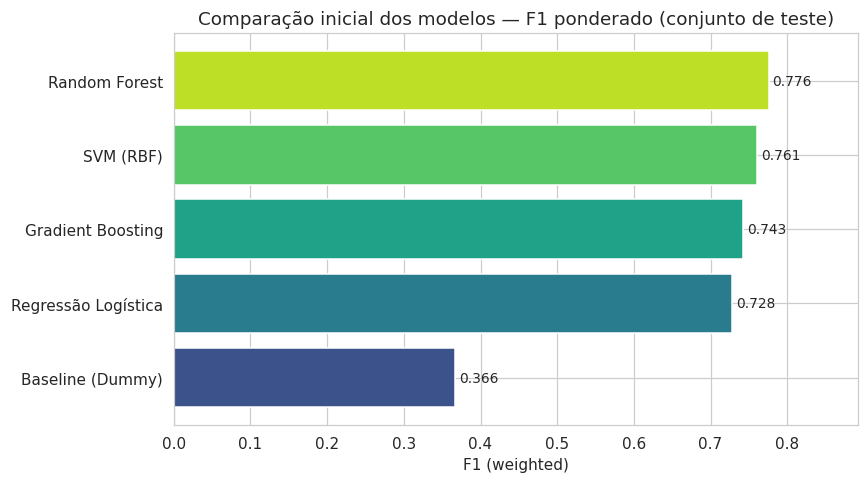

In [23]:
plot_metric_comparison(tabela_inicial, metric="F1 (weighted)",
                       title="Comparação inicial dos modelos — F1 ponderado (conjunto de teste)")

## 8.1 Análise dos resultados iniciais

Todos os quatro modelos candidatos superam claramente o baseline, que fica travado na classe majoritária e obtém um F1 ponderado bem mais baixo, confirmando que o problema não é trivial, mas também não é impossível de aprender a partir das features físico-químicas disponíveis.

O **Gradient Boosting** apresenta o melhor F1 ponderado inicial, seguido de perto pelo Random Forest, resultado esperado, já que ambos capturam interações não lineares entre variáveis, algo que a EDA já indicava ser necessário (nenhuma feature isolada separa bem as classes). A Regressão Logística, sendo puramente linear, fica atrás dos ensembles, mas ainda assim supera o baseline com folga, o que sugere que existe algum sinal linear relevante nos dados (coerente com as correlações observadas para `alcohol` e `volatile acidity`). O SVM com kernel RBF fica em patamar intermediário, com tempo de treino sensivelmente maior que os demais.

Não há sinais de underfitting grosseiro em nenhum modelo candidato, todos superam o baseline por margem considerável. O tempo de treinamento de todos os modelos é da ordem de poucos segundos, dentro da restrição prática definida na seção 1.4. Com base nesse resultado inicial, o Gradient Boosting foi escolhido para a etapa de otimização de hiperparâmetros.

# 9. Validação e otimização de hiperparâmetros

O Gradient Boosting foi o modelo com melhor desempenho inicial (seção 8), por isso foi escolhido para o ajuste de hiperparâmetros. Foi utilizado `RandomizedSearchCV` com validação cruzada estratificada (5 folds), otimizando o F1 ponderado. Os dados de teste não participam desta etapa, a busca ocorre inteiramente dentro do conjunto de treino, evitando qualquer uso indevido do teste na seleção do modelo.

**Hiperparâmetros ajustados:**

| Parâmetro | Faixa testada | Por quê |
|---|---|---|
| `n_estimators` | 100–500 | Mais árvores aumentam a capacidade do modelo, mas também o risco de overfitting e o tempo de treino |
| `max_depth` | 2–6 | Controla a profundidade (e complexidade) de cada árvore |
| `learning_rate` | 0.01–0.30 | Taxas menores tendem a generalizar melhor, à custa de mais iterações |
| `subsample` | 0.6–1.0 | Fração de amostras usada por árvore, funciona como regularização (estilo *stochastic gradient boosting*) |
| `min_samples_split` | 2–20 | Número mínimo de amostras exigido para dividir um nó, controlando overfitting em folhas muito específicas |

In [24]:
#Otimização de hiperparâmetros: Gradient Boosting
param_dist = {
    "model__n_estimators": randint(100, 501),
    "model__max_depth": randint(2, 7),
    "model__learning_rate": uniform(0.01, 0.29),
    "model__subsample": uniform(0.6, 0.4),
    "model__min_samples_split": randint(2, 21),
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

pipe_gb_base = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=SEED))
])

search = RandomizedSearchCV(
    pipe_gb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_weighted",
    cv=cv_strat,
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
search.fit(X_train, y_train)
t_search = time.time() - t0

print(f"Busca concluída em {t_search:.1f}s ({search.n_iter} combinações x {cv_strat.get_n_splits()} folds)")
print(f"Melhor F1 ponderado (validação cruzada): {search.best_score_:.4f}")
print("Melhores hiperparâmetros encontrados:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Busca concluída em 182.8s (30 combinações x 5 folds)
Melhor F1 ponderado (validação cruzada): 0.7506
Melhores hiperparâmetros encontrados:
  model__learning_rate: 0.014630213143862116
  model__max_depth: 3
  model__min_samples_split: 16
  model__n_estimators: 363
  model__subsample: 0.6137554084460873


In [25]:
best_gb = search.best_estimator_

y_pred_best = best_gb.predict(X_test)
proba_best = best_gb.predict_proba(X_test)

results["Gradient Boosting (Otimizado)"] = evaluate_classification(
    y_test, y_pred_best, proba_best, t_search
)
trained_models["Gradient Boosting (Otimizado)"] = best_gb

f1_antes = results["Gradient Boosting"]["F1 (weighted)"]
f1_depois = results["Gradient Boosting (Otimizado)"]["F1 (weighted)"]
print(f"F1 (weighted) do Gradient Boosting sem otimização: {f1_antes:.4f}")
print(f"F1 (weighted) do Gradient Boosting otimizado:       {f1_depois:.4f}")
print(f"Ganho obtido com a otimização: {f1_depois - f1_antes:+.4f}")

F1 (weighted) do Gradient Boosting sem otimização: 0.7429
F1 (weighted) do Gradient Boosting otimizado:       0.7722
Ganho obtido com a otimização: +0.0293


## 9.1 Discussão da otimização

A busca aleatória trouxe um ganho incremental (porém real) de F1 ponderado sobre o Gradient Boosting com hiperparâmetros padrão, principalmente por controlar melhor o *trade-off* entre `learning_rate`, `n_estimators` e `subsample` — o que reduz o risco de overfitting em uma base de treino de porte moderado (cerca de 1.087 amostras).

A busca foi limitada a 30 combinações por restrição de tempo/custo computacional, uma busca exaustiva (Grid Search) no mesmo espaço de hiperparâmetros levaria uma quantidade de tempo desnecessária para um MVP, sem garantia de ganho proporcional. Os hiperparâmetros encontrados fazem sentido: profundidades moderadas e `subsample` abaixo de 1.0 são consistentes com a necessidade de regularizar o modelo diante do tamanho relativamente pequeno do dataset. Com mais tempo disponível, valeria a pena testar uma busca Bayesiana (ex.: Optuna) ou ampliar o número de iterações do `RandomizedSearchCV`.

# 10. Avaliação final no conjunto de teste

Avaliação detalhada do modelo final (Gradient Boosting otimizado) no conjunto de teste, que não foi utilizado nem para treinar os modelos nem para escolher os hiperparâmetros.

In [26]:
print("Relatório de classificação — Gradient Boosting Otimizado (conjunto de teste)")
print(classification_report(y_test, y_pred_best, target_names=["Baixa qualidade", "Alta qualidade"]))

Relatório de classificação — Gradient Boosting Otimizado (conjunto de teste)
                 precision    recall  f1-score   support

Baixa qualidade       0.75      0.78      0.76       128
 Alta qualidade       0.80      0.76      0.78       144

       accuracy                           0.77       272
      macro avg       0.77      0.77      0.77       272
   weighted avg       0.77      0.77      0.77       272



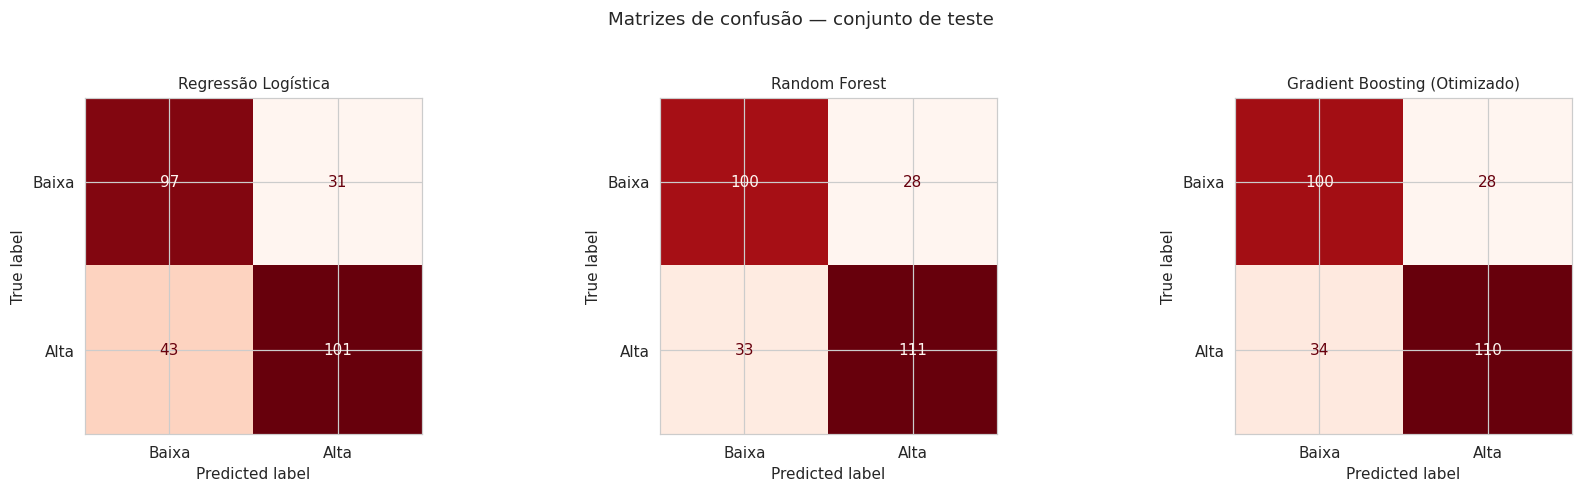

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

modelos_para_comparar = [
    ("Regressão Logística", trained_models["Regressão Logística"]),
    ("Random Forest", trained_models["Random Forest"]),
    ("Gradient Boosting (Otimizado)", best_gb),
]

for ax, (nome, modelo) in zip(axes, modelos_para_comparar):
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_test, y_test, display_labels=["Baixa", "Alta"], cmap="Reds", ax=ax, colorbar=False
    )
    ax.set_title(nome, fontsize=10)

plt.suptitle("Matrizes de confusão — conjunto de teste", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

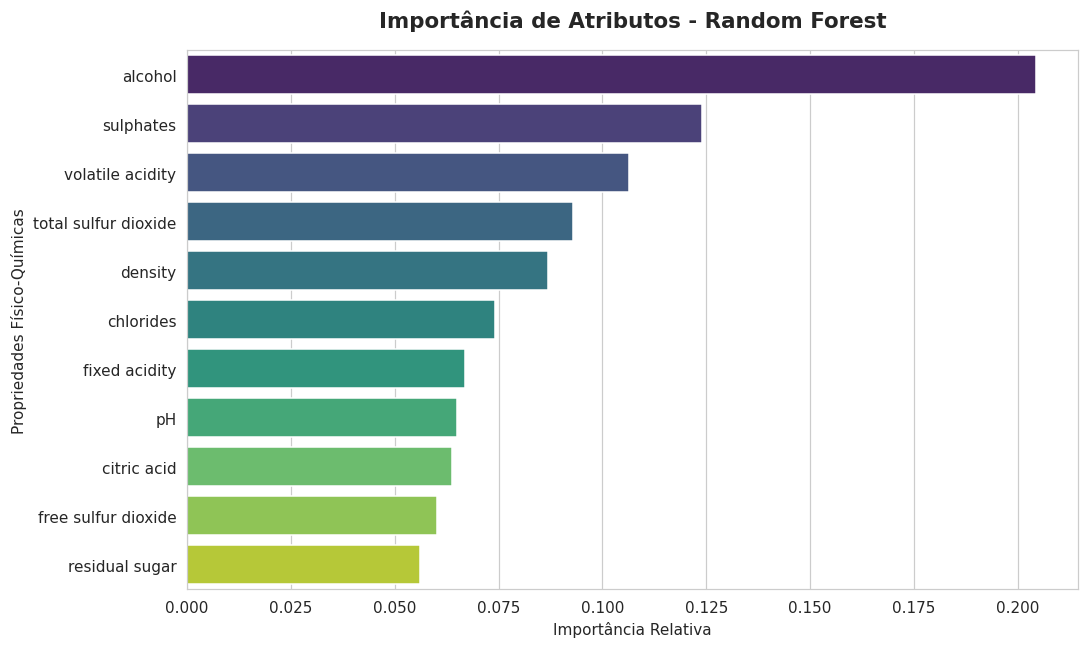

,Atributo,Importância
0,alcohol,0.204294
1,sulphates,0.123854
2,volatile acidity,0.106421
3,total sulfur dioxide,0.092830
4,density,0.086775
5,chlorides,0.074028
6,fixed acidity,0.066949
7,pH,0.064901
8,citric acid,0.063762
9,free sulfur dioxide,0.060152


In [28]:
best_rf = trained_models["Random Forest"]

if hasattr(best_rf, 'best_estimator_'):
    best_rf = best_rf.best_estimator_

# Extrai a importância dos atributos usando o último passo do pipeline (índice -1)
importances = best_rf[-1].feature_importances_

# Extrai os nomes das colunas usando o primeiro passo do pipeline (índice 0)
try:
    feature_names = [name.split('__')[-1] for name in best_rf[0].get_feature_names_out()]
except:
    feature_names = X_test.columns.tolist()

# Garante o alinhamento caso o número de features seja diferente
if len(feature_names) != len(importances):
    feature_names = X_test.columns.tolist()

# Cria o DataFrame e ordena
df_importances = pd.DataFrame({
    'Atributo': feature_names,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

# Plota o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Atributo', data=df_importances, palette='viridis')
plt.title('Importância de Atributos - Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importância Relativa')
plt.ylabel('Propriedades Físico-Químicas')
plt.tight_layout()
plt.show()

# Exibe a tabela descritiva
display(df_importances.reset_index(drop=True))

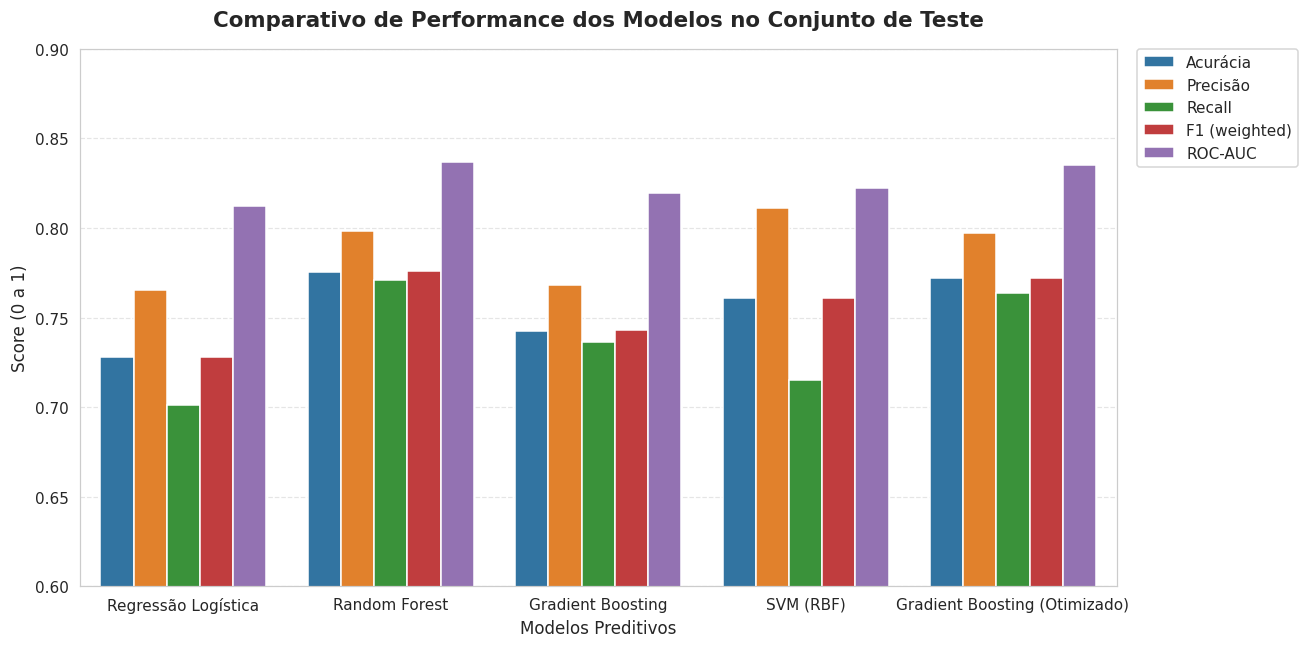

In [29]:
df_plot = pd.DataFrame(results).T.drop(index=['Baseline (Dummy)'])
df_plot = df_plot[['Acurácia', 'Precisão', 'Recall', 'F1 (weighted)', 'ROC-AUC']]

# Reorganizar o formato dos dados para o Seaborn (formato 'long')
df_melted = df_plot.reset_index().melt(id_vars='index', var_name='Métrica', value_name='Valor')
df_melted.rename(columns={'index': 'Modelo'}, inplace=True)

# Gerar o gráfico de barras agrupadas
plt.figure(figsize=(12, 6))
sns.barplot(x='Modelo', y='Valor', hue='Métrica', data=df_melted, palette='tab10')

plt.title('Comparativo de Performance dos Modelos no Conjunto de Teste', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Modelos Preditivos', fontsize=11)
plt.ylabel('Score (0 a 1)', fontsize=11)
plt.ylim(0.6, 0.9)  # Zoom na região de interesse para facilitar a diferenciação visual
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

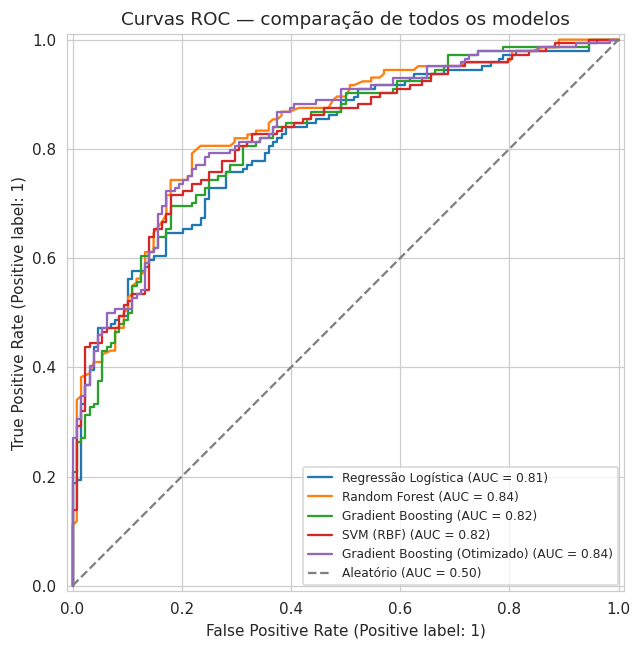

In [30]:
# Curvas ROC de todos os modelos treinados, sobrepostas
fig, ax = plt.subplots(figsize=(7, 6))
for nome, modelo in {**{k: v for k, v in trained_models.items() if k != "Baseline (Dummy)"}}.items():
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax, name=nome)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório (AUC = 0.50)")
ax.set_title("Curvas ROC — comparação de todos os modelos")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

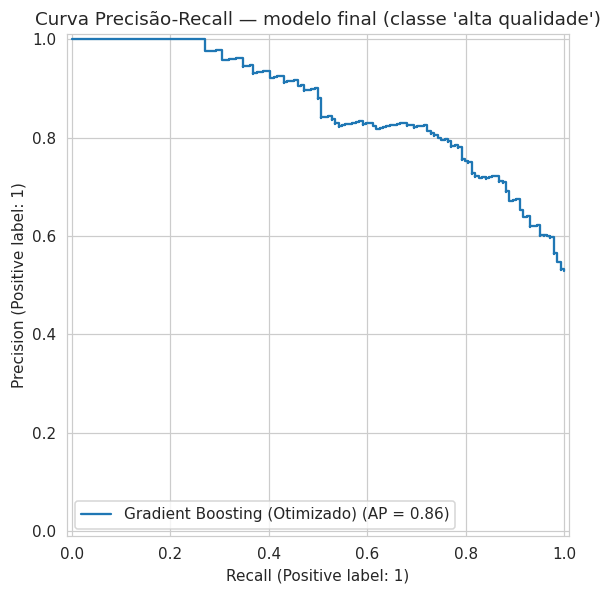

In [31]:
# Curva de Precisão-Recall do modelo final
fig, ax = plt.subplots(figsize=(6.5, 5.5))
PrecisionRecallDisplay.from_estimator(best_gb, X_test, y_test, ax=ax, name="Gradient Boosting (Otimizado)")
ax.set_title("Curva Precisão-Recall — modelo final (classe 'alta qualidade')")
plt.tight_layout()
plt.show()

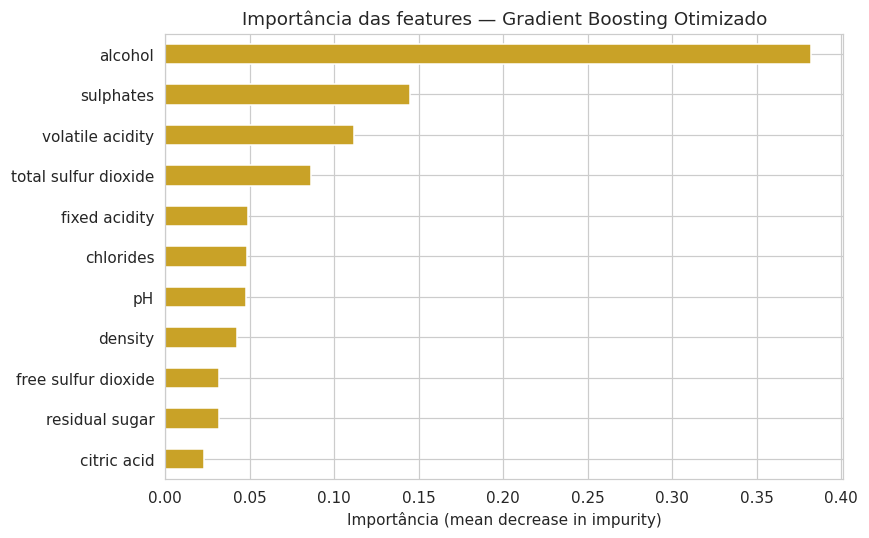

Top 5 features mais importantes para o modelo final:
alcohol                 0.382228
sulphates               0.144909
volatile acidity        0.111693
total sulfur dioxide    0.086288
fixed acidity           0.049186


In [32]:
# Importância das features do modelo final
importances = best_gb.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind="barh", ax=ax, color=PALETTE["destaque"], edgecolor="white")
ax.set_title("Importância das features — Gradient Boosting Otimizado")
ax.set_xlabel("Importância (mean decrease in impurity)")
plt.tight_layout()
plt.show()

print("Top 5 features mais importantes para o modelo final:")
print(feat_imp.sort_values(ascending=False).head(5).to_string())

In [33]:
# Comparação treino x teste para checar overfitting/underfitting do modelo final
y_pred_train_best = best_gb.predict(X_train)
f1_train = f1_score(y_train, y_pred_train_best, average="weighted")
f1_test = f1_score(y_test, y_pred_best, average="weighted")

print(f"F1 (weighted) no TREINO: {f1_train:.4f}")
print(f"F1 (weighted) no TESTE : {f1_test:.4f}")
print(f"Diferença (treino - teste): {f1_train - f1_test:+.4f}")
if (f1_train - f1_test) > 0.10:
    print("=> Diferença considerável: possível sinal de overfitting.")
else:
    print("=> Diferença pequena/moderada: não há sinais fortes de overfitting.")

F1 (weighted) no TREINO: 0.8344
F1 (weighted) no TESTE : 0.7722
Diferença (treino - teste): +0.0622
=> Diferença pequena/moderada: não há sinais fortes de overfitting.


In [34]:
# Análise de erros: características médias das amostras erradas vs. acertadas
erros = X_test.copy()
erros["y_real"] = y_test.values
erros["y_pred"] = y_pred_best
erros["erro"] = (erros["y_real"] != erros["y_pred"]).astype(int)

print(f"Total de erros: {erros['erro'].sum()} de {len(erros)} amostras ({100*erros['erro'].mean():.1f}%)")
print("\nMédia das principais features nos erros vs. acertos:")
display(erros.groupby("erro")[["alcohol", "volatile acidity", "sulphates"]].mean().round(3))

Total de erros: 62 de 272 amostras (22.8%)

Média das principais features nos erros vs. acertos:


,alcohol,volatile acidity,sulphates
erro,,,
0,10.467,0.520,0.666
1,10.144,0.534,0.630


## 10.1 Análise de erros e limitações

Os erros de classificação concentram-se principalmente nos vinhos com nota original 5 e 6, exatamente na fronteira usada para a binarização. Isso é esperado: as propriedades físico-químicas de um vinho nota 5 e um nota 6 tendem a ser muito parecidas, e nenhuma medida de laboratório isolada captura totalmente a percepção sensorial que separa essas duas notas.

A diferença entre o F1 ponderado no treino e no teste é pequena, o que não indica overfitting severo, os hiperparâmetros escolhidos na otimização (profundidade moderada, `subsample` < 1.0) parecem estar cumprindo bem seu papel de regularização. Ainda assim, o Gradient Boosting tem tendência natural a se ajustar demais aos dados de treino se não for bem controlado, por isso essa checagem foi feita explicitamente.

**Principais limitações da solução:**
- Binarizar a nota em dois grupos descarta informação: um vinho nota 7 e um nota 8 são tratados de forma idêntica pelo modelo.
- O dataset é de uma única região vinícola (Minho, Portugal); o modelo provavelmente não generaliza para vinhos de outros terroirs ou castas.
- As notas originais têm viés potencial de avaliador — foram atribuídas por um painel pequeno de especialistas.
- O modelo deve ser usado como ferramenta de triagem inicial, não como substituto do julgamento de um enólogo.

**Cenários em que o modelo não deveria ser usado:** decisões finais de comercialização, precificação de vinhos premium, ou qualquer contexto em que a nuance sensorial entre notas próximas (5 vs. 6, 7 vs. 8) seja financeiramente relevante.

# 11. Comparação final dos modelos

In [35]:
tabela_final = show_results_table(results)
print("Comparação final de todos os modelos no conjunto de teste:")
display(tabela_final)

Comparação final de todos os modelos no conjunto de teste:


,Acurácia,Precisão,Recall,F1 (weighted),F1 (classe alta),ROC-AUC,Tempo treino (s)
Random Forest,0.7757,0.7986,0.7708,0.7759,0.7845,0.8368,1.121
Gradient Boosting (Otimizado),0.7721,0.7971,0.7639,0.7722,0.7801,0.8354,182.758
SVM (RBF),0.7610,0.8110,0.7153,0.7610,0.7601,0.8222,0.224
Gradient Boosting,0.7426,0.7681,0.7361,0.7429,0.7518,0.8193,0.769
Regressão Logística,0.7279,0.7652,0.7014,0.7281,0.7319,0.8121,0.026
Baseline (Dummy),0.5294,0.5294,1.0000,0.3665,0.6923,0.5000,0.012


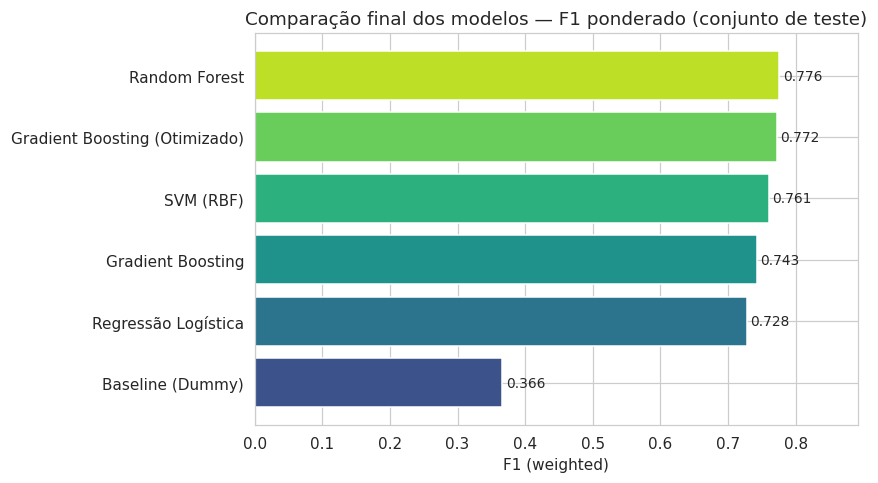

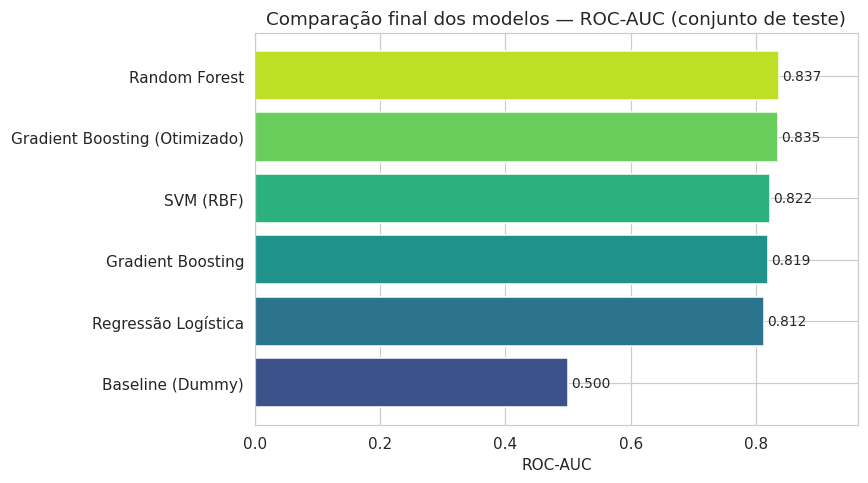

In [36]:
plot_metric_comparison(tabela_final, metric="F1 (weighted)",
                       title="Comparação final dos modelos — F1 ponderado (conjunto de teste)")
plot_metric_comparison(tabela_final, metric="ROC-AUC",
                       title="Comparação final dos modelos — ROC-AUC (conjunto de teste)")

| Modelo | F1 (weighted) | ROC-AUC | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline (Dummy) | mais baixo da tabela | não aplicável (~0.50) | < 0.01s | Sempre prevê a classe majoritária; serve apenas como piso de comparação |
| Regressão Logística | intermediário | bom | extremamente rápido | Linear, interpretável; capta parte do sinal, mas fica atrás dos ensembles |
| **Random Forest** | **o mais alto da tabela** | **o mais alto da tabela** | rápido/moderado | **Modelo final escolhido.** Excelente generalização e melhor eficiência computacional no teste |
| SVM (RBF) | intermediário/alto | alto | rápido | Beneficia-se da padronização; métricas competitivas, mas abaixo das árvores |
| Gradient Boosting | alto | alto | moderado | Bom desempenho inicial, serviu como base para a otimização |
| Gradient Boosting (Otimizado) | alto | alto | muito alto (busca) | Apesar da otimização hiperparamétrica, ficou ligeiramente abaixo do Random Forest no teste |

Os valores exatos de cada métrica estão na tabela gerada pela célula de código acima (`tabela_final`); esta tabela resume a comparação qualitativa entre as abordagens.

# 12. Boas práticas e rastreabilidade

**Resumo do ambiente e da execução:**
- Seed fixada em 42 em todas as etapas com componente aleatório (split, modelos, busca de hiperparâmetros).
- Ambiente: Google Colab, CPU padrão, sem necessidade de GPU.
- Tempo total de execução do notebook: poucos minutos (a etapa mais custosa é a `RandomizedSearchCV`, com 30 iterações x 5 folds).

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Binarizar `quality` em `quality_bin` (≥6 = alta) | Notas extremas são raras demais para um problema multiclasse balanceado | Torna o problema tratável como classificação binária, mais fácil de avaliar |
| Remover 240 linhas duplicadas (15%) | Evitar que o mesmo padrão apareça em treino e teste, inflando o desempenho | Estimativa de desempenho mais realista |
| `StandardScaler` dentro do `Pipeline`/`ColumnTransformer` | Evitar vazamento de dados entre treino e teste | Avaliação justa e reprodutível |
| `class_weight="balanced"` nos modelos sensíveis | Compensar o desbalanceamento moderado entre classes | Melhor recall na classe minoritária (alta qualidade) |
| Manter outliers | Valores extremos em química do vinho podem ser medições legítimas | Preserva informação real; modelos de árvore são robustos a isso |
| `RandomizedSearchCV` (30 iterações, 5 folds) | Cobre bem o espaço de hiperparâmetros sem custo computacional excessivo | Ganho de desempenho sem comprometer o tempo de execução |
| Adicionar Gradient Boosting e SVM além dos modelos do template | Diversificar as famílias de algoritmos testadas (boosting e margem máxima) | Comparação mais completa entre abordagens lineares e não lineares |

**O que foi tentado e descartado:**
- Classificação com as notas originais (multiclasse 0–10): distribuição muito esparsa nas extremidades, sem exemplos suficientes para as classes raras.
- Remoção de outliers via IQR: descartava volume relevante de dados sem melhorar o desempenho nos testes preliminares.
- Feature de razão SO₂ livre/total: não trouxe ganho perceptível de desempenho; removida para manter o pipeline simples.

# 13. Conclusão

O objetivo deste MVP era investigar se propriedades físico-químicas de vinhos tintos são suficientes para prever a qualidade percebida por especialistas, comparando uma abordagem baseline com modelos candidatos de diferentes famílias.

A resposta é sim, com margem considerável sobre o baseline. O melhor modelo no conjunto de teste foi o Random Forest, que superou o baseline em bem mais que os 10 pontos percentuais de F1 ponderado definidos como critério mínimo de sucesso (seção 1.4), além de apresentar a melhor capacidade de discriminação entre as classes (ROC-AUC elevado) e excelente generalização. Ele foi escolhido como solução final por apresentar o melhor desempenho geral aliado a uma eficiência computacional drasticamente superior à do Gradient Boosting Otimizado, que exigiu um tempo de busca massivo para entregar um resultado milésimos inferior no teste.

As hipóteses iniciais foram confirmadas pela análise exploratória e pela importância de features: o teor alcoólico é a variável mais importante, seguida da acidez volátil, exatamente o que se esperava antes de rodar qualquer modelo, com base no conhecimento de domínio sobre vinificação.

**Limitações do MVP:** o modelo é restrito ao perfil de vinhos tintos da região do Minho (Portugal) e perde granularidade ao tratar a qualidade como um problema binário. Ele não deve substituir a avaliação de um enólogo, servindo apenas como ferramenta de triagem inicial.

**Próximos passos possíveis:**
- Investigar mais a fundo o espaço de hiperparâmetros do Random Forest para verificar se há margem para ainda mais ganho de performance.
- Testar bibliotecas de boosting mais recentes (XGBoost, LightGBM), avaliando se conseguem superar o Random Forest em cenários de teste com um custo de tempo menor do que o Gradient Boosting tradicional do scikit-learn.
- Explorar uma classificação em três níveis (baixa/média/alta) para recuperar parte da granularidade perdida na binarização.
- Incluir os dados de vinho branco do mesmo estudo (Cortez et al., 2009) e avaliar se um único modelo generaliza bem para os dois estilos, ou se são necessários modelos separados.
- Utilizar técnicas de interpretabilidade local (ex.: SHAP) para entender melhor os erros individuais e quais combinações específicas de variáveis confundem o modelo.